# Unobserved Confounders: Diagnosis and Repair

Ice cream sales and shark attacks rise and fall together. Ban ice cream and nobody is
safer — **summer heat drives both**. It is the textbook confounder precisely because the
absurdity is obvious. It stops being obvious when the hidden driver is a market factor behind two credit
spreads, or a policy shift behind two economic series. And it stops being harmless the
moment you hand the data to an algorithm, because the algorithm cannot see the
absurdity — it sees only that two series move together, and it draws the arrow.

The [Beginner's Guide](beginners_guide.ipynb) lists three assumptions that observational
discovery rests on. The third is **causal sufficiency**: no hidden common causes among
your observed variables. It is the assumption most likely to be false in practice,
because it is a claim about the columns you **did not** collect. This notebook is about what happens when it breaks:

1. Watch a discovery algorithm invent the ice-cream-causes-sharks edge, and measure what
   believing it would cost.
2. See why there is no one-line patch.
3. Diagnose *which kind* of confounding a dataset has.
4. Repair it with **LUCID**, the deconfounding layer in this library.

In [1]:
import warnings

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

warnings.filterwarnings("ignore")

from causalts.cdnots.phase3_utils import run_cdnots
from causalts.ci_tests import ParCorrGPU
from causalts.confounders import run_lucid, tetrad_filter
from causalts.plotting import plot_graph
from causalts.utils.helpers import evaluate_graph

# Colourblind-safe categorical order (Okabe-Ito), fixed - never cycled.
C_BASE, C_FIXED, C_LUCID = "#0072B2", "#E69F00", "#009E73"

# Lay graphs out with graphviz's sfdp, scaling nodes apart rather than invoking its
# overlap-removal pass (which needs a triangulation library many builds omit).
GV = {"args": "-Goverlap=scale -Gsplines=true"}

---

## Part 1 — Watching the Assumption Break

Let us build the summer exactly as the story tells it. Heat drives ice cream sales
quickly — people buy on a hot day. It drives shark encounters more slowly: the heat has
to fill the beaches first, and only then do swimmers meet sharks.

So `Heat` reaches `IceCream` after one step and `Attacks` after two. **There is no arrow
from ice cream to sharks.** Because every link is lagged, time fixes all the directions.

In [2]:
rng = np.random.default_rng(7)
T = 1500

heat = rng.standard_normal(T)                          # the hidden driver
icecream = np.zeros(T)
attacks = np.zeros(T)
for t in range(2, T):
    icecream[t] = 1.3 * heat[t - 1] + 0.4 * rng.normal()   # Heat(t-1) -> IceCream(t)
    attacks[t] = 1.2 * heat[t - 2] + 0.4 * rng.normal()    # Heat(t-2) -> Attacks(t)

summer = pd.DataFrame({"Heat": heat, "IceCream": icecream, "Attacks": attacks})
print(f"corr(IceCream(t-1), Attacks(t)) = "
      f"{np.corrcoef(icecream[1:-1], attacks[2:])[0, 1]:+.2f}"
      "   <- looks exactly like ice cream causing shark attacks")

corr(IceCream(t-1), Attacks(t)) = +0.90   <- looks exactly like ice cream causing shark attacks


Now run discovery twice — once with `Heat` in the data, once without. The *summer* is
identical; only the **column we collected** differs.

Heat collected : ['Heat(t-1) -> IceCream(t)', 'Heat(t-2) -> Attacks(t)']
Heat hidden    : ['IceCream(t-1) -> Attacks(t)']


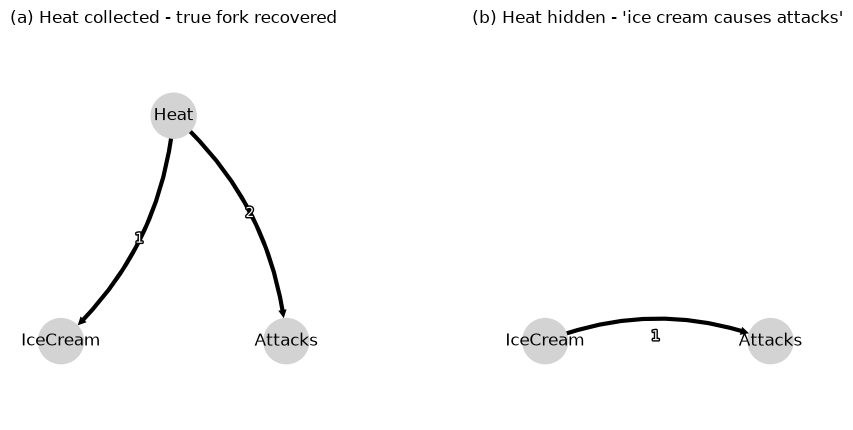

In [3]:
def discover(frame, k, max_lag=2):
    r = run_cdnots(frame, ParCorrGPU(frame.values.copy()), num_lags=max_lag,
                   include_C=True, c_preset="linear", alpha=0.05, verbose=False)
    return np.asarray(r.cg_tig)[:k, :k, : max_lag + 1], r


g_full, _ = discover(summer, 3)                                # sufficiency holds
g_obs, base_xy = discover(summer[["IceCream", "Attacks"]], 2)  # sufficiency violated


def edge_list(g, names):
    return [f"{names[i]}(t-{lag}) -> {names[j]}(t)"
            for lag in range(g.shape[2]) for i in range(len(names))
            for j in range(len(names)) if g[i, j, lag]]


print("Heat collected :", edge_list(g_full, ["Heat", "IceCream", "Attacks"]))
print("Heat hidden    :", edge_list(g_obs, ["IceCream", "Attacks"]))

fork = {"x": np.array([0.5, 0.0, 1.0]), "y": np.array([1.0, 0.0, 0.0])}
pair = {"x": np.array([0.0, 1.0]), "y": np.array([0.0, 0.0])}   # same y-span as (a)
fig, axes = plt.subplots(1, 2, figsize=(11, 4.4))
plot_graph(g_full, val_matrix=None, var_names=["Heat", "IceCream", "Attacks"],
           fig_ax=(fig, axes[0]), node_pos=fork)
plot_graph(g_obs, val_matrix=None, var_names=["IceCream", "Attacks"],
           fig_ax=(fig, axes[1]), node_pos=pair)
for ax, t in zip(axes, ["(a) Heat collected - true fork recovered",
                        "(b) Heat hidden - 'ice cream causes attacks'"]):
    ax.set_ylim(-0.35, 1.35)          # common vertical span so the titles line up
    ax.set_title(t, fontsize=12, pad=10)
plt.tight_layout(); plt.show()

> **💡 The algorithm is not wrong — the data is incomplete**
>
> With `Heat` collected, discovery recovers the fork exactly: `Heat(t-1) → IceCream(t)`
> and `Heat(t-2) → Attacks(t)`, and no link between ice cream and sharks. Drop that one
> column and it returns a single edge: **`IceCream(t-1) → Attacks(t)`**.
>
> Given only those two series, that is the result the algorithm is entitled to
> return: under causal sufficiency it is the right answer. They really
> are dependent, ice cream sales really do come first, and with `Heat` absent there is
> nothing to condition on that would explain the dependence away.
>
> Notice what the lag bought the algorithm: **confidence**. There is no orientation
> ambiguity — time settles the direction — so it does not hedge. It commits to a
> direction, and the direction is nonsense.
>
> Causal sufficiency cannot in general be verified from the observed data alone — it is a
> claim about what is **missing** from it. Particular violations can still leave
> detectable signatures, and finding those is what the rest of this notebook is about.

---

## Part 2 — What It Costs: The Graph Stops Answering Interventional Questions

A causal graph is not a summary of correlations. It is a claim about **what happens if
you intervene** — an arrow `IceCream → Attacks` promises that changing ice cream
sales moves shark attacks.

That promise is testable, and here it has a policy reading: **if we banned ice cream,
would shark attacks fall?** Compare how attacks vary across the ice cream sales we
*observed* against how they respond when we *set* sales ourselves — written `do(·)`.
When the effect is genuine and nothing is confounding it, these coincide; when a hidden
cause is doing the work, they part company.

In [4]:
# Observational: how do attacks track last period's ice cream sales?
slope_obs = np.polyfit(icecream[1:-1], attacks[2:], 1)[0]

# do(IceCream): re-run the same data-generating MECHANISM (a fresh summer), but SET
# sales ourselves - a price cap, a ban, whatever. The sharks' mechanism is unchanged,
# and notice that it never mentions ice cream.
rng2 = np.random.default_rng(11)
heat2 = rng2.standard_normal(T)
icecream_do = rng2.standard_normal(T) * icecream.std()      # <- we set it
attacks2 = np.zeros(T)
for t in range(2, T):
    attacks2[t] = 1.2 * heat2[t - 2] + 0.4 * rng2.normal()  # <- unchanged mechanism
slope_do = np.polyfit(icecream_do[1:-1], attacks2[2:], 1)[0]

print(f"observational   dAttacks/dIceCream     = {slope_obs:+.2f}   <- what the data shows")
print(f"interventional  dAttacks/do(IceCream)  = {slope_do:+.2f}   <- what a ban achieves")

observational   dAttacks/dIceCream     = +0.85   <- what the data shows
interventional  dAttacks/do(IceCream)  = +0.00   <- what a ban achieves


> **⚠️ Read this graph as causal and you will act on nothing**
>
> The observational slope is large; the interventional slope is essentially zero.
> Closing every ice cream stand on the coast changes nothing, because the sharks'
> mechanism never mentioned ice cream.
>
> The failure is not a slightly-wrong coefficient. It is a graph that recommends pulling
> a lever which is not attached to anything. Under violated sufficiency a discovered
> graph is a **statistical** object; treating it as causal is the error, not the
> algorithm.
>
> Practically: discovered edges are hypotheses to corroborate — with domain knowledge, a
> sensitivity analysis, or a real experiment — before anyone acts on them. Effect
> estimation on top of a confounded graph (see
> [`effect_estimation.ipynb`](effect_estimation.ipynb)) inherits the same bias.

---
## Part 3 — The Same Problem at Two Different Scales

The natural response to Part 1 is: *measure the confounder*. But if the hidden cause were
known and available to measure, it would not be hidden in the first place.

What we can observe instead is the **footprint it leaves behind**. And that footprint
depends on how much of the observed system the confounder affects.

In Part 1, we deliberately kept the example small: one hidden cause acting on two
observed series. With a larger system, an important distinction appears. A hidden cause
might affect only a small subset of the variables, or it might influence nearly all of
them.

These are two different regimes of confounding. When the effect is confined to a small
part of the system, we call it **local**. When the same hidden driver reaches broadly
across the system, we call it **pervasive**.

To make the distinction concrete, we now expand the toy example to eight observed
series. Below are two otherwise identical systems with the same genuine causal
structure: **traffic today drives rentals tomorrow**. The only thing we change is how
many of the observed variables are also affected by the hidden heat.

In one system, heat touches only a few variables. In the other, it reaches almost all of
them. As we will see, that difference changes both the pattern of false edges and the
kind of correction we should apply.

In [5]:
cols = ["IceCream", "Attacks", "Parking", "Sunscreen",
        "Crowds", "Traffic", "Rentals", "Drownings"]


def beach_town(n_touched, seed=3, T=1500):
    """Eight series. Heat reaches `n_touched` of them; one real edge throughout."""
    rng = np.random.default_rng(seed)
    heat = rng.standard_normal(T)
    X = rng.standard_normal((T, 8))
    for j in range(n_touched):                      # heat arrives after 1 or 2 steps
        d = (j % 2) + 1
        X[d:, j] += 1.3 * heat[:-d]
    for t in range(1, T):                           # the one true edge
        X[t, 6] += 0.6 * X[t - 1, 5]                # Traffic(t-1) -> Rentals(t)
    return pd.DataFrame(X, columns=cols)


town_local = beach_town(2)      # heat reaches 2 of 8 series  (Part 1, scaled up)
town_wide = beach_town(8)       # heat reaches all 8

for name, town in [("heat reaches 2 of 8", town_local), ("heat reaches all 8", town_wide)]:
    r = run_cdnots(town, ParCorrGPU(town.values.copy()), num_lags=2, include_C=True,
                   c_preset="linear", alpha=0.05, verbose=False)
    g = np.asarray(r.cg_tig)[:8, :8, :3]
    found = int(sum(g[i, j, lag] for lag in range(3)
                    for i in range(8) for j in range(8) if i != j))
    print(f"{name:22s} edges reported: {found:3d}   (exactly 1 is real)")

heat reaches 2 of 8    edges reported:  10   (exactly 1 is real)
heat reaches all 8     edges reported:  38   (exactly 1 is real)


Nine false edges in the first town; thirty-seven in the second. The hidden cause is the
same sun, but the damage it creates is very different. In the first town, confounding is
**local**: most of the system is unaffected, and the spurious structure is concentrated
in one corner. In the second, it is **pervasive**: the hidden driver reaches nearly every
series, and false relationships spread throughout the graph.

That distinction matters because the two cases call for different repairs. A correction
aggressive enough to remove pervasive confounding can destroy genuine structure when the
confounding is only local. So before correcting anything, we first need to determine
which regime the data are in — without observing the hidden cause itself.

Fortunately, the two regimes leave different signatures. Fit a simple autoregressive
model and examine the variation it fails to explain. When a hidden driver moves many
series together, that shared variation remains in the residuals. In their correlation
matrix, it appears as a small number of unusually large eigenvalues.

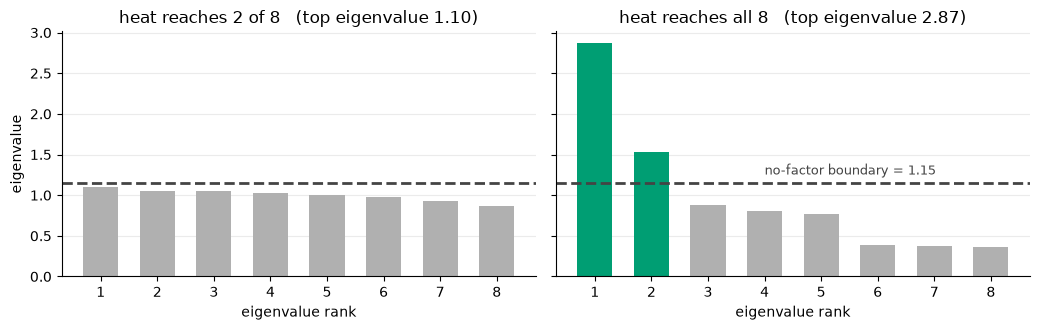

In [6]:
def var_residuals(frame, p=1):
    """What a VAR(p) fit leaves unexplained."""
    X = frame.values
    Y = X[p:]
    Z = np.column_stack([np.ones(len(Y))] + [X[p - 1 - k: len(X) - 1 - k] for k in range(p)])
    beta, *_ = np.linalg.lstsq(Z, Y, rcond=None)
    return Y - Z @ beta


def spectrum(frame):
    U = var_residuals(frame)
    eig = np.sort(np.linalg.eigvalsh(np.corrcoef(U, rowvar=False)))[::-1]
    return eig, (1 + np.sqrt(frame.shape[1] / len(U))) ** 2


fig, axes = plt.subplots(1, 2, figsize=(10.5, 3.4), sharey=True)
for ax, (frame, name) in zip(axes, [(town_local, "heat reaches 2 of 8"),
                                    (town_wide, "heat reaches all 8")]):
    eig, edge = spectrum(frame)
    ax.bar(range(1, len(eig) + 1), eig, width=0.62,
           color=[C_LUCID if e > edge else "#B0B0B0" for e in eig])
    ax.axhline(edge, color="#444444", lw=2, ls="--")
    ax.set_title(f"{name}   (top eigenvalue {eig[0]:.2f})")
    ax.set_xlabel("eigenvalue rank")
    ax.spines[["top", "right"]].set_visible(False)
    ax.grid(axis="y", alpha=0.25); ax.set_axisbelow(True)
axes[0].set_ylabel("eigenvalue")
axes[1].annotate(f"no-factor boundary = {edge:.2f}", xy=(4.0, edge), xytext=(0, 6),
                 textcoords="offset points", fontsize=9, color="#444444")
plt.tight_layout(); plt.show()

The dashed line is the same in both panels. It is the Marchenko–Pastur upper edge: the
boundary that residual eigenvalues stay below when there is no latent factor at all.

In the first town nothing reaches it — the heat is there, but it disturbs too small a
corner of the system to stand out. In the second, two eigenvalues clear it comfortably.
The distinction the previous cell showed in *consequences* is visible here in the data
itself, before any graph is drawn.

That gives us the two regimes, and what can be done about each:

| Regime | Fingerprint | What can be done |
|---|---|---|
| **Sparse** | residuals stay essentially full-rank | prune edges that do not survive adjustment for a small set of observed predictors |
| **Pervasive** | a few directions dominate the spectrum | attenuate those directions, then rebuild the affected structure from what remains |

&nbsp;

> **💡 Why one correction cannot serve both**
>
> Each repair is harmful in the other's regime. Attenuating the dominant directions of a
> sparse system discards genuine structure, because nothing up there is confounding to
> begin with. Pruning against observed predictors is powerless once the sun touches
> everything — every candidate predictor is contaminated by the same driver.
>
> Note the modest wording in the table. Neither repair recovers the hidden variable, and
> neither is a general solution to a latent fork: conditioning on series you *did* measure
> cannot block a path running through one you did not. What they remove is the
> *footprint*. That is a weaker claim than identification, and it is the honest one.
>
> So a method must work out which regime it is in before it corrects anything. Making that
> call from the data is what **LUCID** adds.

---

## Part 4 — A Realistic Case: Pervasive Factor Confounding

Three latent GARCH factors, each driving a group of series, plus genuine lag-1 edges
*within* groups. This is the shape of a market panel: everything responds to a few shared
drivers, and the drivers are not in your table.

observed: T=1500, d=15   latent factors: 3 (not in the data)
true cross-variable edges (6): [(0, 1, 1), (1, 2, 1), (5, 6, 1), (6, 7, 1), (10, 11, 1), (11, 12, 1)]
plus a genuine AR(1) self-loop on each of the 15 series


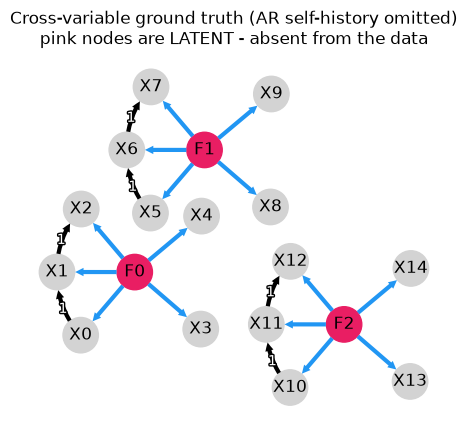

In [7]:
def make_garch_factor_data(d=15, n_factors=3, T=1500, seed=42):
    """Latent GARCH factors + sparse true lag-1 edges. Returns observed data only.

    The causal edges are part of the recursion, not added to a finished series:
    assembling one lag-1 coefficient matrix and stepping the system once is what makes
    the returned `gt` match the cross-variable lag-1 edges that generated the data.

    `gt` covers cross-variable structure only. Every series also carries a genuine
    AR(1) term, which is why the scoring below excludes self-loops rather than
    counting them as errors.
    """
    assert n_factors >= 1 and d % n_factors == 0, "equal-sized factor groups"
    assert d // n_factors >= 3, "each group needs room for two chained edges"
    rng = np.random.default_rng(seed)
    group_size = d // n_factors

    factors = np.zeros((T, n_factors))
    sigma2 = np.ones(n_factors)
    for t in range(1, T):
        sigma2 = 0.01 + 0.1 * factors[t - 1] ** 2 + 0.85 * sigma2
        factors[t] = rng.normal(0, np.sqrt(sigma2))

    # Lag-1 coefficients, A[target, source]: AR(1) on the diagonal plus the true edges.
    A = 0.3 * np.eye(d)
    gt = np.zeros((d, d, 2), dtype=int)
    true_edges = []
    for g in range(n_factors):
        start = g * group_size
        for e in range(2):
            src, tgt = start + e, start + e + 1
            if tgt < (g + 1) * group_size and tgt < d:
                A[tgt, src] += 0.4
                gt[src, tgt, 1] = 1
                true_edges.append((src, tgt, 1))

    loadings = rng.uniform(0.5, 1.5, size=d)
    group_of = np.minimum(np.arange(d) // group_size, n_factors - 1)

    data = np.zeros((T, d))
    for t in range(1, T):
        data[t] = (loadings * factors[t, group_of]     # contemporaneous factor
                   + A @ data[t - 1]                   # AR(1) + true lag-1 edges
                   + 0.3 * rng.normal(size=d))

    gt_full = np.zeros((d + n_factors, d + n_factors, 2), dtype=int)
    gt_full[:d, :d, :] = gt
    for g in range(n_factors):
        for i in range(g * group_size, min((g + 1) * group_size, d)):
            gt_full[d + g, i, 0] = 1
    names_full = [f"X{i}" for i in range(d)] + [f"F{g}" for g in range(n_factors)]

    df = pd.DataFrame(data, columns=[f"X{i}" for i in range(d)])
    return df, gt, true_edges, gt_full, names_full, n_factors


df, gt, true_edges, gt_full, names_full, n_factors = make_garch_factor_data()
d, max_lag = df.shape[1], 1
print(f"observed: T={len(df)}, d={d}   latent factors: {n_factors} (not in the data)")
print(f"true cross-variable edges ({len(true_edges)}): {true_edges}")
print(f"plus a genuine AR(1) self-loop on each of the {d} series")

plot_graph(gt_full, val_matrix=None, var_names=names_full,
           target_node=[f"F{g}" for g in range(n_factors)],
           target_node_color="#E91E63", target_out_color="#E91E63",
           title="Cross-variable ground truth (AR self-history omitted)\npink nodes are LATENT - absent from the data",
           node_layout="sfdp", node_layout_kwargs=GV);

Run discovery and score it. Part 1's failure, multiplied by every pair inside every
group.

CDNOTS alone   F1=0.167   precision=0.095   recall=0.667   SHD=40
  lag-0 edges predicted: 38   (ground truth has 0)


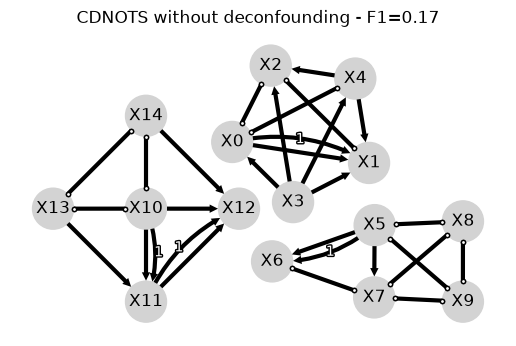

In [8]:
ci = ParCorrGPU(df.values.copy())
base = run_cdnots(df, ci, num_lags=max_lag, include_C=True, c_preset="linear",
                  alpha=0.05, verbose=False)
g_base = np.asarray(base.cg_tig)[:d, :d, : max_lag + 1]

# Every series is autoregressive by construction, so its self-loop is genuine but is
# not the cross-variable structure we are scoring; keep it out of the metrics.
m_base = evaluate_graph(g_base, gt, exclude_self_loops=True)
print(f"CDNOTS alone   F1={m_base['F1']:.3f}   precision={m_base['Precision']:.3f}   "
      f"recall={m_base['TPR']:.3f}   SHD={m_base['SHD']}")
print(f"  lag-0 edges predicted: {int(g_base[:, :, 0].sum())}   "
      f"(ground truth has {int(gt[:, :, 0].sum())})")

plot_graph(g_base, val_matrix=None, var_names=list(df.columns),
           title=f"CDNOTS without deconfounding - F1={m_base['F1']:.2f}",
           node_layout="sfdp", node_layout_kwargs=GV);

On this seed CDNOTS recovers four of the six planted cross-variable edges, so recall
is `0.67`. Precision collapses to `0.10`: it also reports 38 spurious contemporaneous
arrows between observed series, induced by the latent factors, where the truth has none.

---

## Part 5 — Diagnosis Before Repair

`run_lucid` performs the Part 3 test automatically: fit a VAR, take the residual
correlation spectrum, and compare its leading mass against the no-factor null. The
threshold is derived from the Marchenko–Pastur law, so it adapts to `d` and `T` rather
than being a number you tune.

In [9]:
res = run_lucid(df, max_lag)

print(f"regime          : {res.regime}")
print(f"router statistic: R = {res.spectral_ratio:.3f}  vs  tau = {res.tau:.3f}")
print(f"factors detected: {res.n_factors}")
print(f"runtime         : {res.runtime:.2f}s")
print()
for f in range(res.n_factors):
    top = res.top_factor_variables(f, 5)
    print(f"factor {f} loads on: " + ", ".join(f"{v} ({l:+.2f})" for v, l in top))

regime          : pervasive
router statistic: R = 0.499  vs  tau = 0.210
factors detected: 3
runtime         : 0.50s

factor 0 loads on: X0 (-0.55), X4 (-0.49), X2 (-0.45), X1 (-0.41), X3 (-0.29)
factor 1 loads on: X7 (-0.62), X8 (-0.57), X9 (-0.35), X5 (-0.29), X6 (-0.25)
factor 2 loads on: X10 (-0.58), X11 (-0.50), X13 (-0.39), X12 (-0.39), X14 (-0.32)


The router says *pervasive*, finds three factors, and the loadings recover the three
generated groups — `X0–X4`, `X5–X9`, `X10–X14`.

> **⚠️ Loadings describe, they do not identify**
>
> It is tempting to read those groupings as "we found the latent variables." We did not.
> Factor directions are recovered only up to rotation, so a large loading means *this
> variable carries dominant shared variation* — not *this variable has an identified
> hidden parent*.
>
> This is the honest boundary of the method: LUCID removes the **footprint** of latent
> structure. It does not recover the latent structure itself. If you need the ambiguity
> reported explicitly instead, methods like FCI and LPCMCI return a partial ancestral
> graph, where `X <-> Y` states outright that a hidden common cause is present.

---

## Part 6 — The Repair, and Whether Adapting Actually Helps

Having diagnosed *pervasive*, LUCID keeps the lagged edges it discovered and
**reconstructs** the contemporaneous slice: attenuate the factor-dominated directions,
then re-admit only those lag-0 candidates that survive against an edge-free null.

The comparison worth making is not against doing nothing — it is against a **fixed**
deconfounder. `tetrad_filter` always assumes pervasive structure and always strips lag-0
edges consistent with a shared cause. On this dataset that assumption is correct, so it
is a fair fight.

method                   F1    prec  recall   SHD
CDNOTS (none)         0.167   0.095   0.667    40
tetrad (fixed)        0.667   0.667   0.667     4
LUCID (adaptive)      0.800   1.000   0.667     2


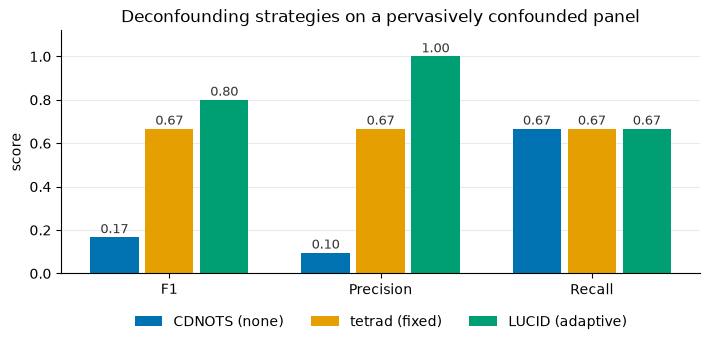

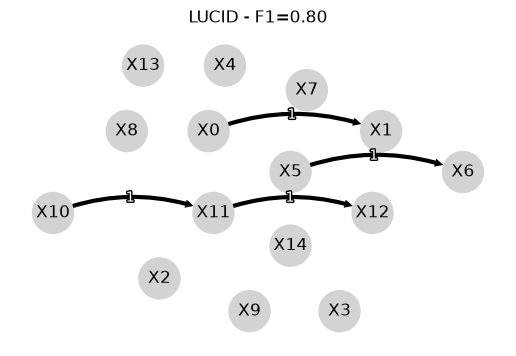

In [10]:
g_lucid = np.asarray(res.cg_tig)
m_lucid = evaluate_graph(g_lucid, gt, exclude_self_loops=True)
g_tet = np.asarray(tetrad_filter(df, g_base, max_lag, threshold=0.25))
m_tet = evaluate_graph(g_tet, gt, exclude_self_loops=True)

rows = [("CDNOTS (none)", m_base, C_BASE),
        ("tetrad (fixed)", m_tet, C_FIXED),
        ("LUCID (adaptive)", m_lucid, C_LUCID)]
print(f"{'method':<20}{'F1':>7}{'prec':>8}{'recall':>8}{'SHD':>6}")
for name, m, _ in rows:
    print(f"{name:<20}{m['F1']:>7.3f}{m['Precision']:>8.3f}{m['TPR']:>8.3f}{m['SHD']:>6}")

metrics, labels = ["F1", "Precision", "TPR"], ["F1", "Precision", "Recall"]
x = np.arange(len(metrics)); w = 0.26
fig, ax = plt.subplots(figsize=(7.2, 3.6))
for i, (name, m, colour) in enumerate(rows):
    vals = [m[k] for k in metrics]
    bars = ax.bar(x + (i - 1) * w, vals, w * 0.88, label=name, color=colour)
    for b, v in zip(bars, vals):           # direct labels (contrast relief)
        ax.annotate(f"{v:.2f}", xy=(b.get_x() + b.get_width() / 2, v),
                    xytext=(0, 3), textcoords="offset points",
                    ha="center", fontsize=9, color="#333333")
ax.set_xticks(x); ax.set_xticklabels(labels)
ax.set_ylim(0, 1.12); ax.set_ylabel("score")
ax.set_title("Deconfounding strategies on a pervasively confounded panel")
ax.legend(frameon=False, ncols=3, loc="upper center", bbox_to_anchor=(0.5, -0.12))
ax.spines[["top", "right"]].set_visible(False)
ax.grid(axis="y", alpha=0.25); ax.set_axisbelow(True)
plt.tight_layout(); plt.show()

res.plot(title=f"LUCID - F1={m_lucid['F1']:.2f}", node_layout="sfdp", node_layout_kwargs=GV);

One panel is one draw. Before reading that ranking as a property of the methods,
repeat the whole comparison across thirty seeds — about half a second each.

In [11]:
seed_rows, regimes = [], []
for s in range(42, 72):
    df_s, gt_s, *_ = make_garch_factor_data(seed=s)
    base_s = run_cdnots(df_s, ParCorrGPU(df_s.values.copy()), num_lags=max_lag,
                        include_C=True, c_preset="linear", alpha=0.05, verbose=False)
    g_b = np.asarray(base_s.cg_tig)[:d, :d, : max_lag + 1]
    res_s = base_s.deconfound()
    regimes.append(res_s.regime)
    for name, g in [("CDNOTS (none)", g_b),
                    ("tetrad (fixed)", np.asarray(tetrad_filter(df_s, g_b, max_lag,
                                                                threshold=0.25))),
                    ("LUCID (adaptive)",
                     np.asarray(res_s.cg_tig)[:d, :d, : max_lag + 1])]:
        m = evaluate_graph(g, gt_s, exclude_self_loops=True)
        seed_rows.append({"seed": s, "method": name, "F1": m["F1"],
                          "precision": m["Precision"], "recall": m["TPR"],
                          "SHD": m["SHD"]})

seed_stats = pd.DataFrame(seed_rows)
n_seeds = seed_stats.seed.nunique()
print(f"{n_seeds} seeds, mean ± sd\n")
print(f"{'method':<20}{'F1':>17}{'precision':>17}{'recall':>17}{'SHD':>16}")
for name in ["CDNOTS (none)", "tetrad (fixed)", "LUCID (adaptive)"]:
    q = seed_stats[seed_stats.method == name]
    print(f"{name:<20}{q.F1.mean():>9.3f}±{q.F1.std():<7.3f}"
          f"{q.precision.mean():>9.3f}±{q.precision.std():<7.3f}"
          f"{q.recall.mean():>9.3f}±{q.recall.std():<7.3f}"
          f"{q.SHD.mean():>8.1f}±{q.SHD.std():<6.1f}")

piv = seed_stats.pivot(index="seed", columns="method", values="F1")
lu, te, cd = piv["LUCID (adaptive)"], piv["tetrad (fixed)"], piv["CDNOTS (none)"]
print(f"\nLUCID vs the fixed filter: {(lu > te).sum()} higher / {(lu == te).sum()} tied"
      f" / {(lu < te).sum()} lower")
print(f"both corrections above CDNOTS on {((te > cd) & (lu > cd)).sum()}/{n_seeds} seeds")
print(f"routed pervasive on {regimes.count('pervasive')}/{n_seeds} seeds")
sh = seed_stats[seed_stats.method == "LUCID (adaptive)"].SHD
print(f"LUCID SHD: median {sh.median():.1f}, spread "
      f"{dict(sorted(sh.astype(int).value_counts().items()))}")
print(f"\nthe panel plotted above is seed 42: LUCID F1 {lu.loc[42]:.3f} against a "
      f"{lu.mean():.3f} mean, gap over the fixed filter {lu.loc[42] - te.loc[42]:.3f} "
      f"against a {(lu - te).mean():.3f} mean gap")

30 seeds, mean ± sd

method                             F1        precision           recall             SHD
CDNOTS (none)           0.201±0.036      0.114±0.021      0.839±0.135      40.4±4.0   
tetrad (fixed)          0.573±0.178      0.465±0.212      0.839±0.135       8.9±5.7   
LUCID (adaptive)        0.901±0.083      0.990±0.039      0.839±0.135       1.0±0.8   

LUCID vs the fixed filter: 28 higher / 2 tied / 0 lower
both corrections above CDNOTS on 30/30 seeds
routed pervasive on 30/30 seeds
LUCID SHD: median 1.0, spread {0: 8, 1: 14, 2: 7, 3: 1}

the panel plotted above is seed 42: LUCID F1 0.800 against a 0.901 mean, gap over the fixed filter 0.133 against a 0.328 mean gap


Over these thirty seeds LUCID's F1 is higher than the fixed filter's on 28 and tied on
the other two, never lower. The single panel above is a below-average draw: its recall,
`0.67`, sits under the `0.84` seed mean, and the gap it shows over the fixed filter
(`0.13`) is about a third of the `0.33` mean gap.

All three rows share the same recall, and here that is mechanical rather than
coincidental. Every planted edge is lag-1; `tetrad_filter` only ever touches the lag-0
slice, and the pervasive branch — which all thirty seeds routed to — rebuilds lag-0 and
returns lag-1 untouched. Neither can recover a lagged edge the base engine missed, so on
this panel recall is inherited from discovery. That is a property of the pervasive route
rather than of deconfounding in general: the sparse branch's post-double-selection filter
tests edges at every lag and can drop a lagged one.

Precision is what separates the methods. `tetrad_filter` applies one fixed assumption to
every dataset — on this pervasively confounded panel that assumption is the right one,
and it reaches a mean F1 of `0.57` (`±0.18`). Deciding per dataset, LUCID reaches `0.90`
(`±0.08`) at a mean precision of `0.99`, with an SHD of 1 as both the median and the most
common outcome (14 of the 30 seeds; 8 more are exact).

Both corrections beat doing nothing — on the plotted seed and
on all thirty. But that margin is not the argument for
routing, and it is worth being precise about what the argument actually is.

The claim is not "LUCID wins a benchmark." It is that **applying the wrong correction
does damage**, and that a method which decides first avoids it. That is testable: take the
two towns from Part 3, where we know the right answer, and force each branch by hand.

                                       no action    routed (LUCID)  forced pervasive     forced sparse
quiet town (truly sparse)                   0.18              0.67              0.29              0.67
busy town (truly pervasive)                 0.05              0.11              0.11              0.06


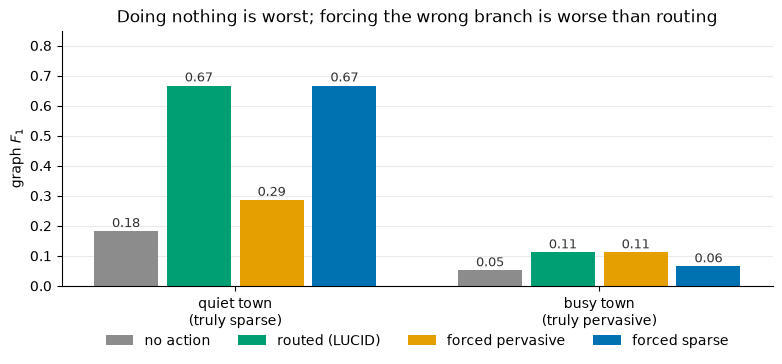

In [12]:
from causalts.confounders.routed_deconf import routed_deconfound

gt_town = np.zeros((8, 8, 3), dtype=int)
gt_town[5, 6, 1] = 1                       # the one real edge: Traffic(t-1) -> Rentals(t)

towns = [("quiet town\n(truly sparse)", town_local), ("busy town\n(truly pervasive)", town_wide)]


def no_action(town):
    """Plain discovery: the graph you get if you ignore confounding entirely."""
    r = run_cdnots(town, ParCorrGPU(town.values.copy()), num_lags=2, include_C=True,
                   c_preset="linear", alpha=0.05, verbose=False)
    return np.asarray(r.cg_tig)[:8, :8, :3]


arms = {"no action": None,                                        # ignore confounding
        "routed (LUCID)": {},                                     # let LUCID decide
        "forced pervasive": dict(router="spectral", thresholds=(0.0, 0.0)),
        "forced sparse": dict(router="spectral", thresholds=(9.9, 9.9))}

scores = {}
for tname, town in towns:
    for aname, kw in arms.items():
        g = no_action(town) if kw is None else np.asarray(routed_deconfound(town, 2, **kw))
        # Same metric domain as Part 4: score cross-variable structure only.
        scores[(tname, aname)] = evaluate_graph(
            g, gt_town, exclude_self_loops=True)["F1"]

print(f"{'':30s}" + "".join(f"{a:>18s}" for a in arms))
for tname, _ in towns:
    print(f"{tname.replace(chr(10), ' '):30s}"
          + "".join(f"{scores[(tname, a)]:>18.2f}" for a in arms))

x = np.arange(len(towns)); w = 0.20
colours = ["#8C8C8C", C_LUCID, C_FIXED, C_BASE]        # grey = do nothing
fig, ax = plt.subplots(figsize=(8.0, 3.8))
for i, (aname, colour) in enumerate(zip(arms, colours)):
    vals = [scores[(t, aname)] for t, _ in towns]
    bars = ax.bar(x + (i - 1.5) * w, vals, w * 0.88, label=aname, color=colour)
    for b, v in zip(bars, vals):
        ax.annotate(f"{v:.2f}", xy=(b.get_x() + b.get_width() / 2, v), xytext=(0, 3),
                    textcoords="offset points", ha="center", fontsize=9, color="#333333")
ax.set_xticks(x); ax.set_xticklabels([t for t, _ in towns])
ax.set_ylabel("graph $F_1$"); ax.set_ylim(0, 0.85)
ax.set_title("Doing nothing is worst; forcing the wrong branch is worse than routing")
ax.legend(frameon=False, ncols=4, loc="upper center", bbox_to_anchor=(0.5, -0.14))
ax.spines[["top", "right"]].set_visible(False)
ax.grid(axis="y", alpha=0.25); ax.set_axisbelow(True)
plt.tight_layout(); plt.show()

There is the argument, in one figure. Force the pervasive correction onto the quiet town
and its score collapses — the machinery attenuates directions that were carrying real
structure, because in that town nothing up there was confounding. Force the sparse
correction onto the busy town and it under-corrects, since every observed series it might
adjust against is contaminated by the same sun.

The routed column is at or above the best arm in **both** towns, and it got there without
being told which town it was in.

> **💡 The value of routing is what it prevents, not what it wins**
>
> On a benchmark you already know the regime, so any correction matched to it will look
> good. On your own data you do not know, and the cost of guessing wrong is the drop you
> see above. Deciding from the data is the whole point.
>
> One caveat on this figure: these towns are small and their absolute scores are low —
> eight series with a single true edge is a hard target. Read the *differences between
> the bars*, not the heights.

---

## Part 7 — Using It On Your Own Data

Two things make this practical. First, the router genuinely switches. Hand it the quiet
town from Part 3 and it takes the other branch:

In [13]:
res_local = run_lucid(town_local, 2)
print(f"quiet town (heat on 2 of 8) -> regime={res_local.regime:<10} "
      f"R={res_local.spectral_ratio:.3f} vs tau={res_local.tau:.3f}   "
      f"pervasive factors detected={res_local.n_factors}")
print(f"GARCH panel                 -> regime={res.regime:<10} "
      f"R={res.spectral_ratio:.3f} vs tau={res.tau:.3f}   "
      f"pervasive factors detected={res.n_factors}")

quiet town (heat on 2 of 8) -> regime=sparse     R=0.269 vs tau=0.374   pervasive factors detected=0
GARCH panel                 -> regime=pervasive  R=0.499 vs tau=0.210   pervasive factors detected=3


Exactly the split Part 3 showed, now made by the method rather than by eye: the quiet
town falls short of its threshold and is routed `sparse`, while the GARCH panel clears
its own by more than twice. Same call, same defaults, different branch — decided from
the data.

> **⚠️ `pervasive factors detected = 0` does not mean "no confounder"**
>
> We *built* the quiet town with hidden heat, and the field still reads zero. It is not
> claiming the town is unconfounded — it is reporting that no **pervasive factor
> direction** cleared the diagnostic. The heat is there; it simply touches too little of
> the system to register as a factor. Read the field as "nothing large and system-wide
> here", never as "nothing hidden here".

Second, LUCID is a **layer**, not a replacement. If you already ran discovery, reuse it —
both branches use the same base engine, so the result is identical and you skip the
expensive step:

In [14]:
reused = base.deconfound()          # `base` is the CdnotsResult from Part 4

print(f"type   : {type(reused).__name__}")
print(f"regime : {reused.regime}")
print(f"identical to run_lucid(df): "
      f"{np.array_equal(np.asarray(reused.cg_tig), np.asarray(res.cg_tig))}")

type   : LucidResult
regime : pervasive
identical to run_lucid(df): True


`.deconfound()` lives on the shared result base class, so it works on a `CdnotsResult`,
`CedarResult` or `GraceResult` alike. The filters are available the same way and return
the *same* result type, so they chain: `result.tetrad_filter().deconfound()`.

---

## Part 8 — Summary and Next Steps

**The failure.** Causal sufficiency is the assumption most likely to be false, because it
concerns data you never collected. When it breaks, discovery fabricates edges between the
variables a hidden cause drives — and the resulting graph stops answering interventional
questions. Part 2 measured the gap: a large observational slope against an interventional
slope of essentially zero.

**Why it needs a diagnosis.** Sparse and pervasive confounding leave different spectral
fingerprints and demand opposite corrections, each harmful in the other's regime. No
fixed rule — including "drop all lag-0 edges" — covers both.

**What LUCID does.** `run_lucid(df, max_lag)` reads the residual spectrum against the
Marchenko–Pastur null, then applies the matching correction. Inspect the decision through
`.regime`, `.spectral_ratio`, `.tau` and `.n_factors`, and reuse existing work with
`result.deconfound()`.

**What it does not do.** It does not identify the latent variables; `factor_loadings` is
descriptive. It reads second-order structure, so nonlinear factor mixing or factors too
weak to clear the null can be misread. And where genuine lag-0 structure overlaps the
factor directions, trimming attenuates signal along with confounding.

Deconfounding improves a graph. It does not turn a discovered graph into an experiment —
treat edges as hypotheses to corroborate.

**Next steps**

- [`beginners_guide.ipynb`](beginners_guide.ipynb) — the assumptions this notebook stresses
- [`effect_estimation.ipynb`](effect_estimation.ipynb) — estimating effects once you
  trust a graph
- [`api_reference.ipynb`](api_reference.ipynb) — the full `causalts` surface